In [17]:
import os
import sys
import seaborn as sns
# Must be set before importing cartridges
os.environ["CARTRIDGES_DIR"] = "/data/workspace/phudish/gated-continual-cartridges"
os.environ["CARTRIDGES_OUTPUT_DIR"] = "/data/workspace/phudish/gated-continual-cartridges/experiments/experiments_1/outputs"

sys.path.insert(0, "/data/workspace/phudish/gated-continual-cartridges")

import torch
import numpy as np
import matplotlib.pyplot as plt

from cartridges.cache import TrainableCache

## Load cartridges

In [18]:
OUTPUTS = "/data/workspace/phudish/gated-continual-cartridges/outputs"

# (label, phase1_path, phase2_path)
# Convention: no-tag AMD2021 → AMD2022, with-tag AMD2021 → Pepsi

PAIRS = [
    # ── Llama 3.2 3B ──────────────────────────────────────────────────────────
    ("Llama | AMD2021→AMD2022 | toks=512",
     f"{OUTPUTS}/2026-03-24-09-31-09-train_initial/79909b2b-2a9c-407b-8b36-0db0f25f6f3f/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-10-08-43-train_continual/f8f2f4f4-36fd-4d60-82f6-5a5e5bf843fd/cache_last.pt"),
    ("Llama | AMD2021→AMD2022 | toks=1024",
     f"{OUTPUTS}/2026-03-24-00-44-14-train_initial/aeb02668-e686-48c8-95a4-d517be380254/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-01-09-04-train_continual/b7e2c843-6949-4f91-9960-fd6a78fc4085/cache_last.pt"),
    ("Llama | AMD2021→AMD2022 | toks=2048",
     f"{OUTPUTS}/2026-03-24-02-12-40-train_initial/958a3914-b06c-4ad6-9ccd-ab749a98fb78/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-03-29-47-train_continual/1150d4c9-c3f8-4783-97eb-c9d5b7abafca/cache_last.pt"),
    ("Llama | AMD2021→Pepsi2021 | toks=512",
     f"{OUTPUTS}/2026-03-24-02-12-18-train_initial/859804cb-7529-4500-9a4d-a0de831180d8/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-03-31-33-train_continual/c4064a62-4130-4c05-a249-08160ef24e00/cache_last.pt"),
    ("Llama | AMD2021→Pepsi2021 | toks=1024",
     f"{OUTPUTS}/2026-03-24-00-51-52-train_initial/bf6965fb-7360-49e0-b63d-3a144927500b/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-01-10-06-train_continual/1586e9f3-3b55-438b-9682-c16a9d9c158e/cache_last.pt"),
    ("Llama | AMD2021→Pepsi2021 | toks=2048",
     f"{OUTPUTS}/2026-03-24-02-26-39-train_initial/89363b00-cdf7-4ba9-9e02-336358b18f99/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-03-44-52-train_continual/3f9bcfa8-df6c-490f-91a9-fc7815eb40d8/cache_last.pt"),

    # ── Qwen3-4B ──────────────────────────────────────────────────────────────
    ("Qwen | AMD2021→AMD2022 | toks=512",
     f"{OUTPUTS}/2026-03-24-08-05-16-train_initial/0c16b246-daa0-4abf-a08d-776ea00782db/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-09-42-14-train_continual/b247ae20-8411-486b-aa80-38d85396b1d0/cache_last.pt"),
    ("Qwen | AMD2021→AMD2022 | toks=1024",
     f"{OUTPUTS}/2026-03-24-08-32-20-train_initial/31190ad0-029a-4160-96c8-6c15f0475103/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-09-44-12-train_continual/ecf0ad32-abf9-45a6-b754-5b63738d34d3/cache_last.pt"),
    ("Qwen | AMD2021→AMD2022 | toks=2048",
     f"{OUTPUTS}/2026-03-24-09-00-38-train_initial/36e44208-7d68-40cd-b4f7-a3d821c7e22e/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-19-05-17-train_continual/7c5d5c9e-7eaf-4895-80d1-d7a9897e4f9a/cache_last.pt"),
    ("Qwen | AMD2021→Pepsi2021 | toks=512",
     f"{OUTPUTS}/2026-03-24-08-05-36-train_initial/925fa9f2-629c-437d-a2e7-37c8f51febe2/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-10-11-43-train_continual/c007c5c7-eacc-4b7c-b8e8-8c708919098a/cache_last.pt"),
    ("Qwen | AMD2021→Pepsi2021 | toks=1024",
     f"{OUTPUTS}/2026-03-24-08-32-47-train_initial/97d3c0d0-c33b-4754-9f56-1fc3cd22d04a/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-10-21-42-train_continual/0a179602-a4cf-41d5-9163-48376c8741d3/cache_last.pt"),
    ("Qwen | AMD2021→Pepsi2021 | toks=2048",
     f"{OUTPUTS}/2026-03-24-09-01-04-train_initial/be39b7e3-1e7e-477b-b4c8-46cf60a010a3/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-10-29-13-train_continual/22ee641a-358e-445e-a8e0-718d53adb445/cache_last.pt"),
]

print(f"{len(PAIRS)} pairs defined")
for label, p1, p2 in PAIRS:
    ok = __import__('os').path.exists(p1) and __import__('os').path.exists(p2)
    print(f"  {'✓' if ok else '✗'} {label}")

12 pairs defined
  ✓ Llama | AMD2021→AMD2022 | toks=512
  ✓ Llama | AMD2021→AMD2022 | toks=1024
  ✓ Llama | AMD2021→AMD2022 | toks=2048
  ✓ Llama | AMD2021→Pepsi2021 | toks=512
  ✓ Llama | AMD2021→Pepsi2021 | toks=1024
  ✓ Llama | AMD2021→Pepsi2021 | toks=2048
  ✓ Qwen | AMD2021→AMD2022 | toks=512
  ✓ Qwen | AMD2021→AMD2022 | toks=1024
  ✓ Qwen | AMD2021→AMD2022 | toks=2048
  ✓ Qwen | AMD2021→Pepsi2021 | toks=512
  ✓ Qwen | AMD2021→Pepsi2021 | toks=1024
  ✓ Qwen | AMD2021→Pepsi2021 | toks=2048


In [19]:
def get_keys_values(cache):
    """Returns keys and values stacked across layers: (n_layers, n_heads, num_tokens, head_dim)"""
    keys = torch.cat([k.data for k in cache.trainable_keys], dim=0)
    values = torch.cat([v.data for v in cache.trainable_values], dim=0)
    return keys, values

# Load all pairs
results = []
for label, p1_path, p2_path in PAIRS:
    print(f"Loading {label}...")
    c1 = TrainableCache.from_pretrained(p1_path, device="cpu")
    c2 = TrainableCache.from_pretrained(p2_path, device="cpu")
    k1, v1 = get_keys_values(c1)
    k2, v2 = get_keys_values(c2)
    results.append((label, k1, v1, k2, v2))
    print(f"  keys shape: {k1.shape}")

print("\nAll loaded.")

Loading Llama | AMD2021→AMD2022 | toks=512...
/data/workspace/phudish/gated-continual-cartridges/outputs/2026-03-24-09-31-09-train_initial/79909b2b-2a9c-407b-8b36-0db0f25f6f3f/cache_last.pt
2026-03-24 19:51:25,024 - cartridges.cache [rank=0] - INFO - num_trainable_tokens: 511
2026-03-24 19:51:25,025 - cartridges.cache [rank=0] - INFO - num_frozen_tokens: 1
/data/workspace/phudish/gated-continual-cartridges/outputs/2026-03-24-10-08-43-train_continual/f8f2f4f4-36fd-4d60-82f6-5a5e5bf843fd/cache_last.pt
2026-03-24 19:51:26,258 - cartridges.cache [rank=0] - INFO - num_trainable_tokens: 511
2026-03-24 19:51:26,259 - cartridges.cache [rank=0] - INFO - num_frozen_tokens: 1
  keys shape: torch.Size([28, 8, 511, 128])
Loading Llama | AMD2021→AMD2022 | toks=1024...
/data/workspace/phudish/gated-continual-cartridges/outputs/2026-03-24-00-44-14-train_initial/aeb02668-e686-48c8-95a4-d517be380254/cache_last.pt
2026-03-24 19:51:28,589 - cartridges.cache [rank=0] - INFO - num_trainable_tokens: 1023
202

## Between-cartridge cosine similarity (AMD 2021 vs AMD 2022)

For each layer, compute the mean cosine similarity between every slot in the AMD 2021 cartridge and every slot in the AMD 2022 cartridge, averaged over heads. Shows how much each layer's KV representations shifted during continual learning on AMD 2022 data.

In [20]:
def between_cartridge_sim(keys_a, keys_b):
    """Mean cosine similarity between corresponding slots per layer and per layer-head.
    
    Computes sim(slot_i_A, slot_i_B) for each i via element-wise dot product after
    normalizing — O(T*D) instead of O(T^2*D), and gives 1.0 when A == B.
    
    Returns: mean per layer (n_layers,), mean per layer-head (n_layers, n_heads)
    """
    # Normalize: (n_layers, n_heads, T, D)
    a = torch.nn.functional.normalize(keys_a.float(), dim=-1)
    b = torch.nn.functional.normalize(keys_b.float(), dim=-1)
    # Element-wise dot product then mean over tokens: (n_layers, n_heads)
    sim = (a * b).sum(dim=-1).mean(dim=-1)
    mean_per_layer = sim.mean(dim=-1).numpy()          # (n_layers,)
    mean_per_layer_head = sim.numpy()                  # (n_layers, n_heads)
    return mean_per_layer, mean_per_layer_head

## Plot: mean similarity per layer (keys and values)

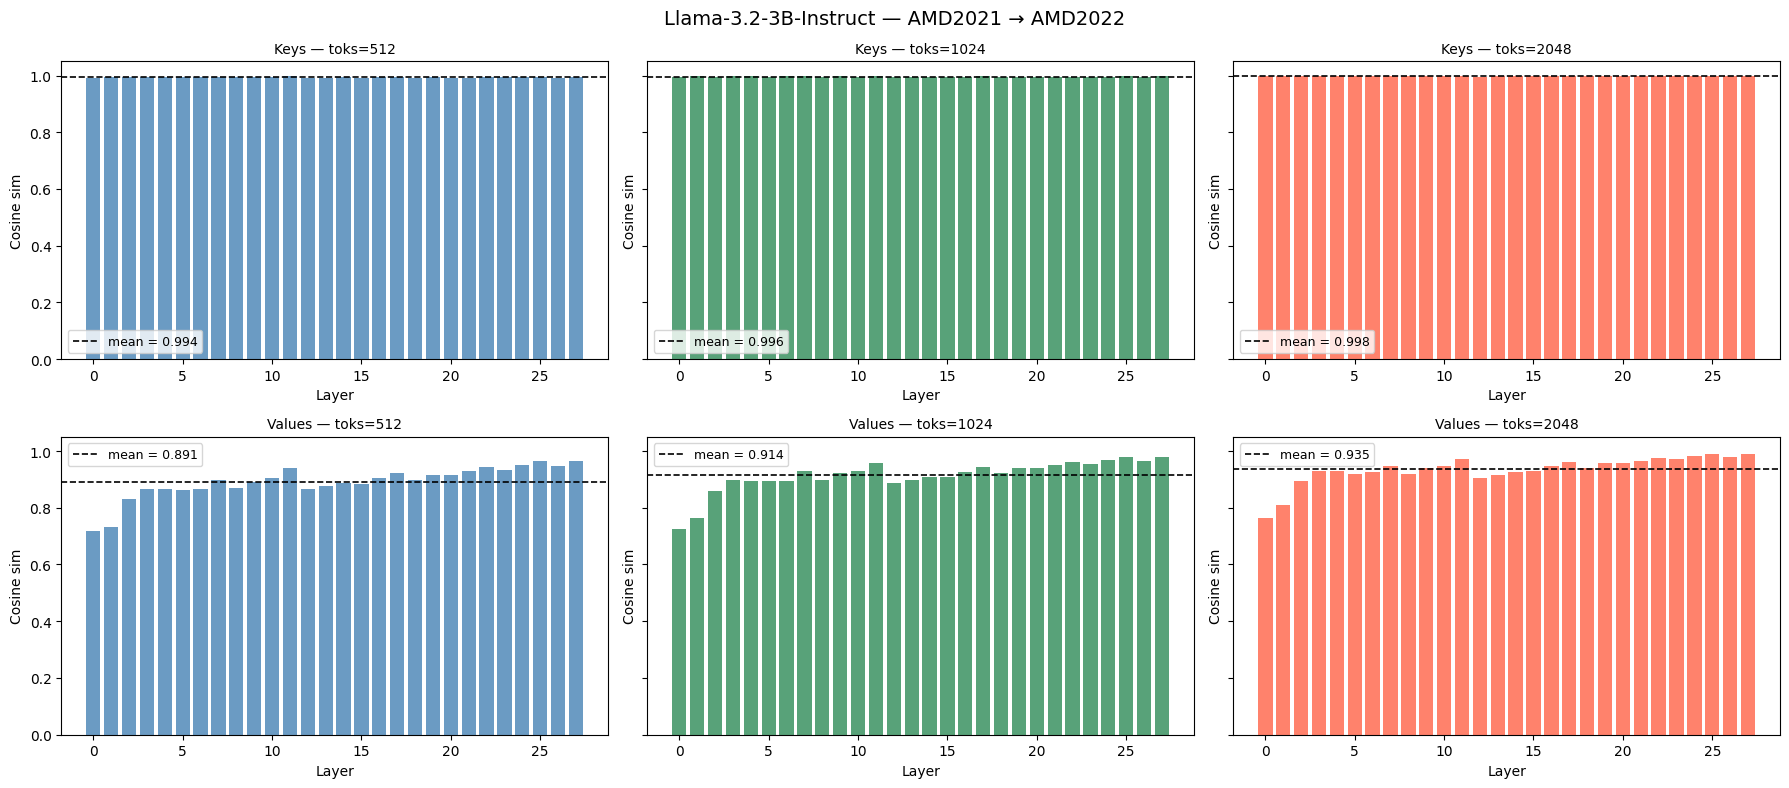

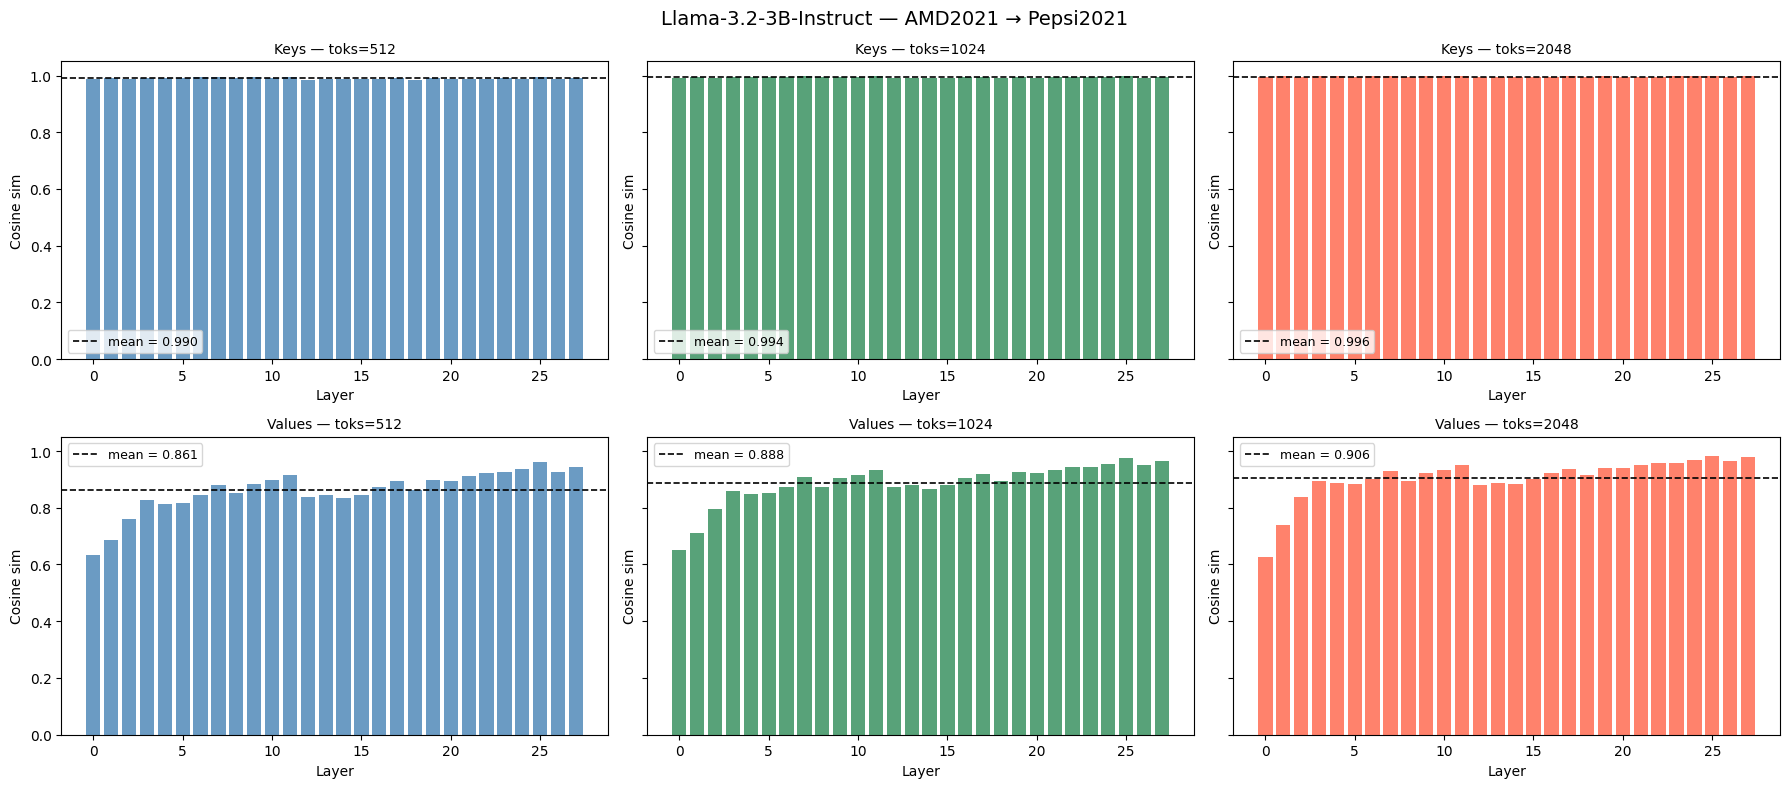

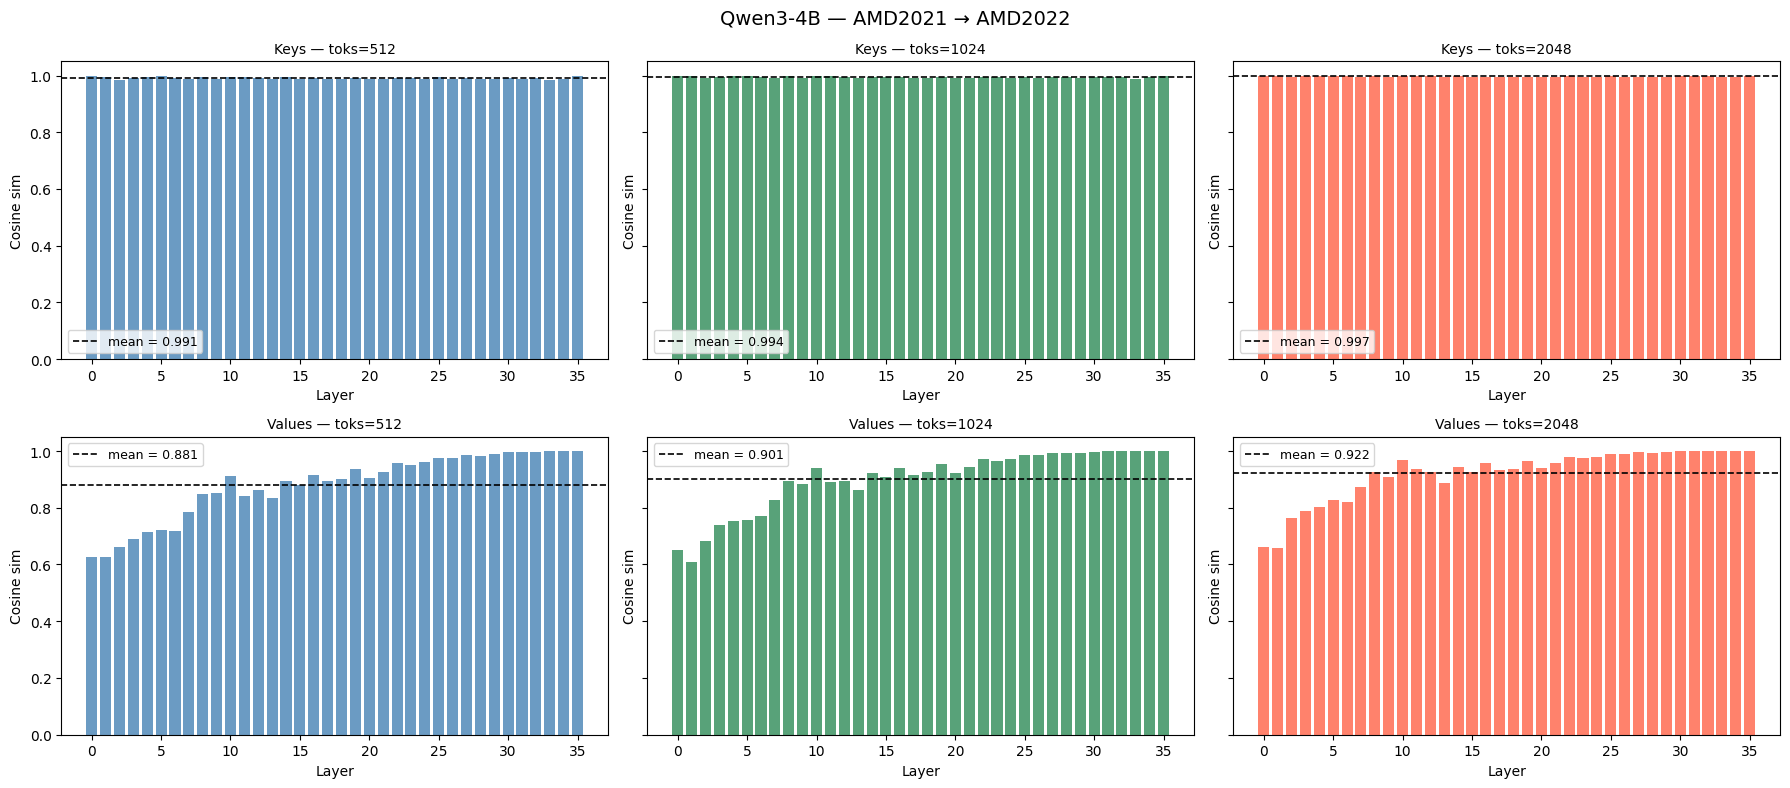

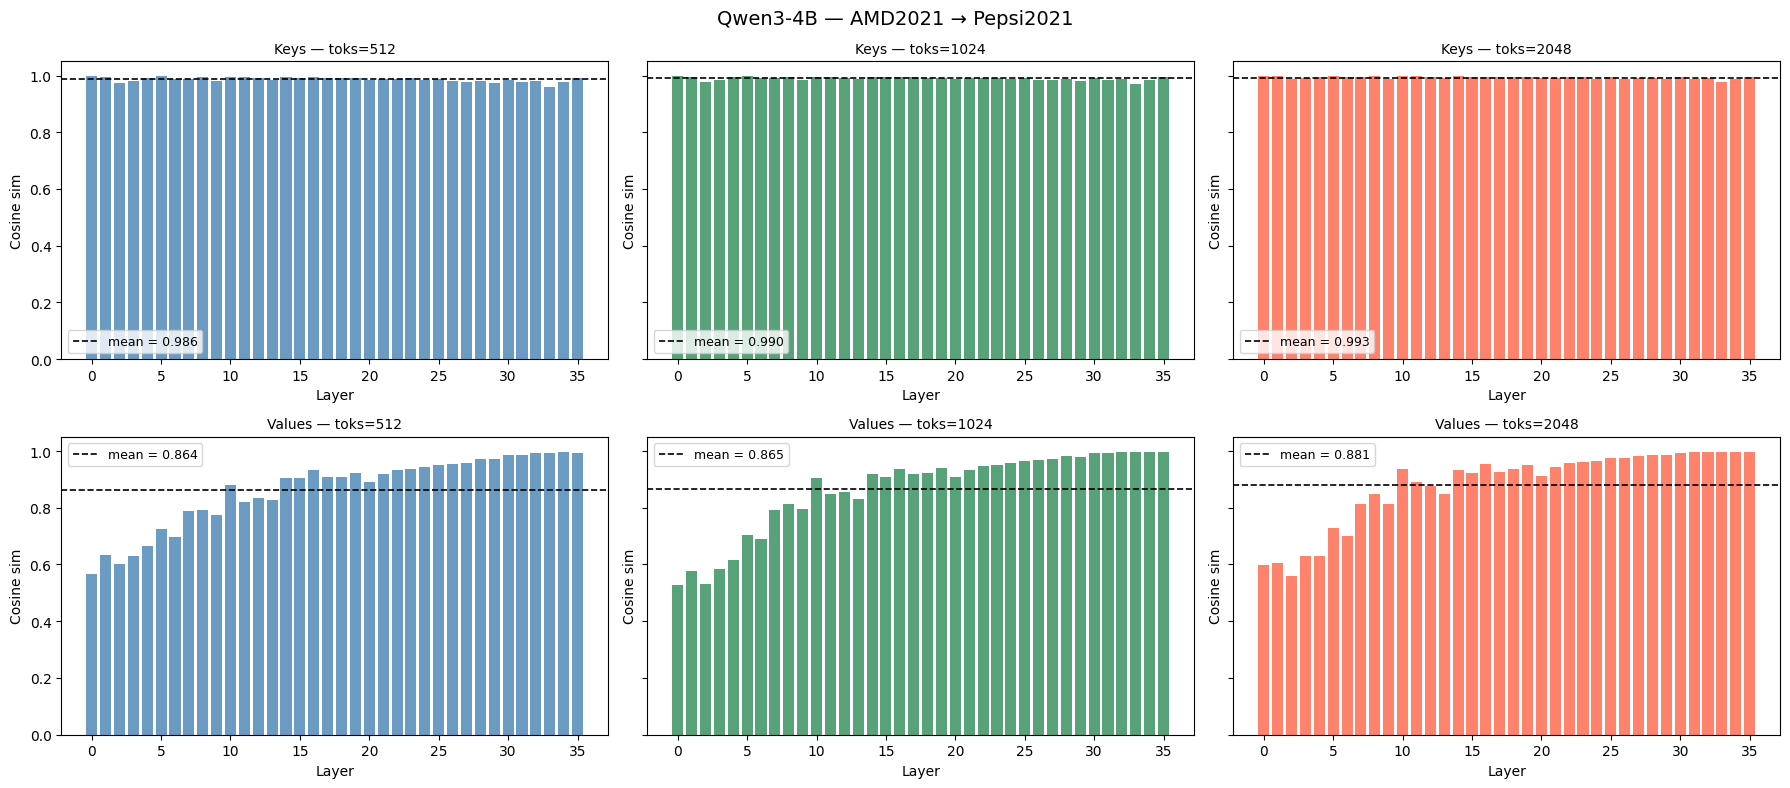

In [23]:
# Compute similarities for all pairs
sim_results = {}
for label, k1, v1, k2, v2 in results:
    key_sim, key_sim_head = between_cartridge_sim(k1, k2)
    val_sim, val_sim_head = between_cartridge_sim(v1, v2)
    sim_results[label] = {
        "key_sim": key_sim,
        "val_sim": val_sim,
        "key_sim_head": key_sim_head,
        "val_sim_head": val_sim_head,
    }

# 4 plots: (Llama/Qwen) x (AMD2022/Pepsi), each with 2 rows (Keys/Values) x 3 cols (toks)
GROUPS = [
    ("Llama-3.2-3B-Instruct — AMD2021 → AMD2022", "Llama", "AMD2022"),
    ("Llama-3.2-3B-Instruct — AMD2021 → Pepsi2021", "Llama", "Pepsi"),
    ("Qwen3-4B — AMD2021 → AMD2022", "Qwen", "AMD2022"),
    ("Qwen3-4B — AMD2021 → Pepsi2021", "Qwen", "Pepsi"),
]
TOK_SIZES = [512, 1024, 2048]
colors = {512: "steelblue", 1024: "seagreen", 2048: "tomato"}

for fig_title, model, target in GROUPS:
    fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
    fig.suptitle(fig_title, fontsize=14)

    for col, toks in enumerate(TOK_SIZES):
        label = f"{model} | AMD2021→{target}2021 | toks={toks}" if target == "Pepsi" \
                else f"{model} | AMD2021→{target} | toks={toks}"
        if label not in sim_results:
            for row in range(2):
                axes[row, col].set_visible(False)
            continue

        data = sim_results[label]
        for row, (kv, kv_title) in enumerate([("key_sim", "Keys"), ("val_sim", "Values")]):
            ax = axes[row, col]
            sim = data[kv]
            layers = np.arange(len(sim))
            ax.bar(layers, sim, color=colors[toks], alpha=0.8)
            ax.axhline(sim.mean(), color="black", linestyle="--", linewidth=1.2,
                       label=f"mean = {sim.mean():.3f}")
            ax.set_title(f"{kv_title} — toks={toks}", fontsize=10)
            ax.set_xlabel("Layer")
            ax.set_ylabel("Cosine sim")
            ax.set_ylim(0, 1.05)
            ax.legend(fontsize=9)

    plt.tight_layout()
    fname = fig_title.lower().replace(" ", "_").replace("→", "to").replace("—", "").strip("_")
    plt.savefig(f"{fname}.png", dpi=150, bbox_inches="tight")
    plt.show()

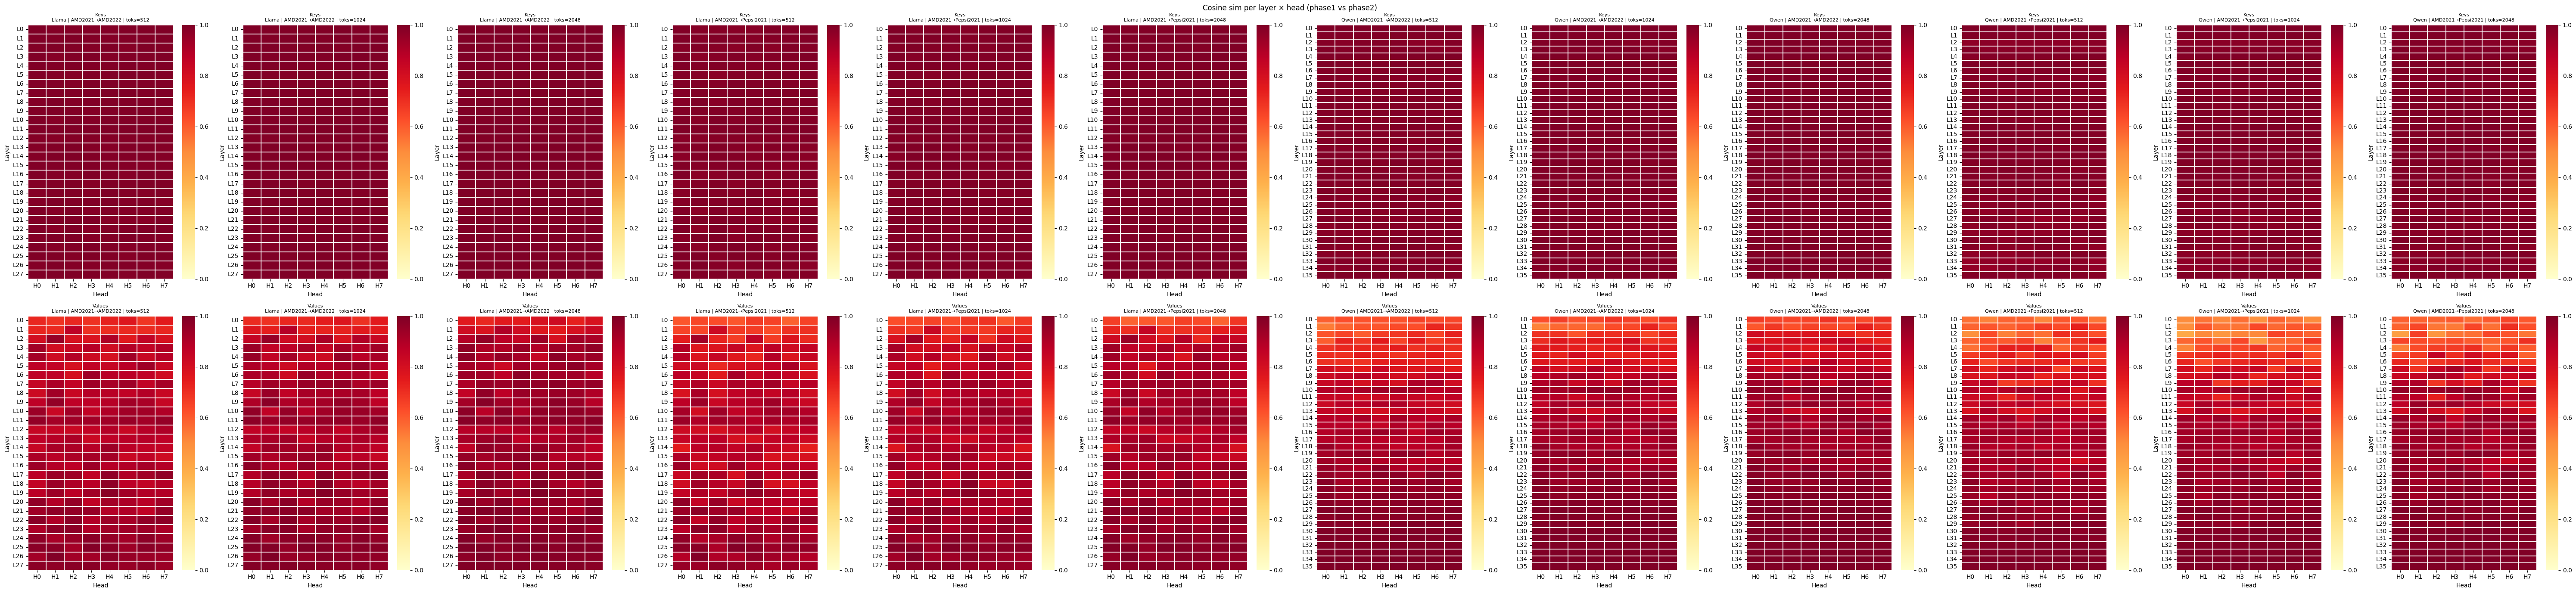

In [24]:
# Heatmaps: layer x head for keys and values, all pairs
n_pairs = len(sim_results)
fig, axes = plt.subplots(2, n_pairs, figsize=(5 * n_pairs, 14))

for col, (label, data) in enumerate(sim_results.items()):
    for row, (kv_key, title) in enumerate([("key_sim_head", "Keys"), ("val_sim_head", "Values")]):
        ax = axes[row, col]
        mat = data[kv_key]
        sns.heatmap(
            mat,
            ax=ax,
            cmap="YlOrRd",
            vmin=0, vmax=1,
            xticklabels=[f"H{h}" for h in range(mat.shape[1])],
            yticklabels=[f"L{l}" for l in range(mat.shape[0])],
            annot=False,
            linewidths=0.2,
            cbar=True,
        )
        ax.set_title(f"{title}\n{label}", fontsize=8)
        ax.set_xlabel("Head")
        ax.set_ylabel("Layer")

plt.suptitle("Cosine sim per layer × head (phase1 vs phase2)", fontsize=12)
plt.tight_layout()
plt.savefig("kv_slot_sim_layer_head_all.png", dpi=150, bbox_inches="tight")
plt.show()